# Galton-style Parent/Child Heights — Simulated Regression

This notebook simulates parent (mid-parent) and child heights inspired by Galton's data, fits a simple linear regression predicting child height from parent height, shows a scatter plot with the regression line (slope annotated), prints the regression summary (coefficients, std err, t, p, R², adjusted R²), and explains key statistics.

In [2]:
%pip install statsmodels pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 3.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 5.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Imports and reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set(style='whitegrid')
np.random.seed(2025)

# Simulation parameters
N = 300
parent_mean = 68.0   # inches (typical adult height)
parent_sd = 2.8      # variability in mid-parent
true_slope = 0.50    # regression slope (Galton-ish: regression toward the mean)
true_intercept = 32.0
noise_sd = 2.5       # residual standard deviation

# Simulate mid-parent heights and child heights
parent = np.random.normal(parent_mean, parent_sd, size=N)
child = true_intercept + true_slope * parent + np.random.normal(0, noise_sd, size=N)

df = pd.DataFrame({'parent': parent, 'child': child})
df.head()


,parent,child
0,67.741308,64.306099
1,70.056000,66.884018
2,63.971130,64.173007
3,66.142418,62.169873
4,67.717961,64.936629


In [4]:
# Fit OLS regression using statsmodels
X = sm.add_constant(df['parent'])  # adds intercept column
model = sm.OLS(df['child'], X).fit()

# Extract summary statistics
intercept_hat = model.params['const']
slope_hat = model.params['parent']
r2 = model.rsquared
adj_r2 = model.rsquared_adj
stderr_intercept = model.bse['const']
stderr_slope = model.bse['parent']

print(f"Estimated intercept: {intercept_hat:.4f} (std err {stderr_intercept:.4f})")
print(f"Estimated slope:     {slope_hat:.4f} (std err {stderr_slope:.4f})")
print(f"R^2:                 {r2:.4f}")
print(f"Adjusted R^2:        {adj_r2:.4f}")
print('\nFull statsmodels summary:')
print(model.summary())


Estimated intercept: 28.6321 (std err 3.4782)
Estimated slope:     0.5464 (std err 0.0512)
R^2:                 0.2765
Adjusted R^2:        0.2741

Full statsmodels summary:
                            OLS Regression Results                            
Dep. Variable:                  child   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     113.9
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           9.88e-23
Time:                        11:51:48   Log-Likelihood:                -683.51
No. Observations:                 300   AIC:                             1371.
Df Residuals:                     298   BIC:                             1378.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err    

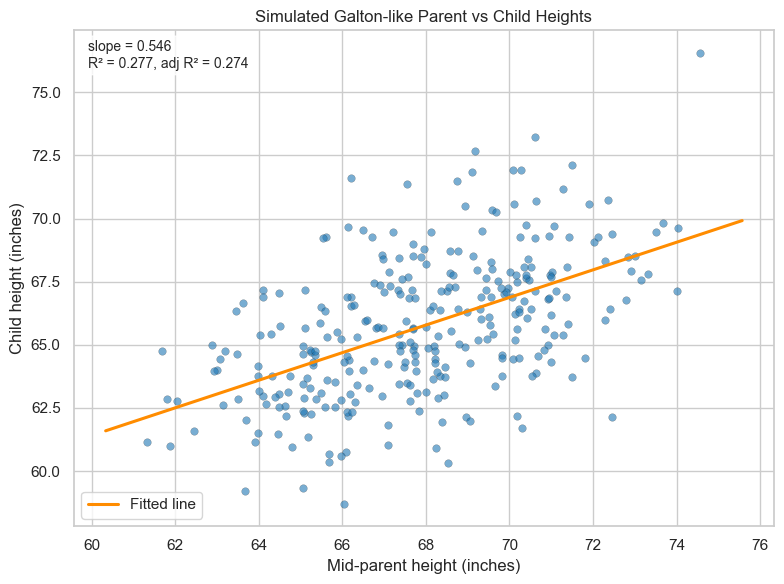

In [5]:
# Scatter plot with regression line and annotations
plt.figure(figsize=(8,6))
plt.scatter(df['parent'], df['child'], s=30, alpha=0.6, color='tab:blue', edgecolor='k', linewidth=0.2)

# Regression line
x_vals = np.linspace(df['parent'].min() - 1, df['parent'].max() + 1, 200)
y_vals = intercept_hat + slope_hat * x_vals
plt.plot(x_vals, y_vals, color='darkorange', linewidth=2.2, label='Fitted line')

# Annotate slope and R^2 on the plot
slope_text = f"slope = {slope_hat:.3f}"
r2_text = f"R² = {r2:.3f}, adj R² = {adj_r2:.3f}"
plt.text(0.02, 0.98, slope_text + '\n' + r2_text, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Mid-parent height (inches)')
plt.ylabel('Child height (inches)')
plt.title('Simulated Galton-like Parent vs Child Heights')
plt.legend()
plt.tight_layout()
plt.show()


## Interpreting the regression output

- **Coefficient (slope)**: the estimated slope tells us how much child height changes on average per one-inch increase in mid-parent height. If slope ≈ 0.5, then a 2-inch increase in parent corresponds to about a 1-inch increase in the child on average.
- **Intercept**: predicted child height when the parent height is 0 (usually not meaningful by itself; the slope is what matters within the data range).
- **R² (coefficient of determination)**: the proportion of variance in child heights explained by the parent height. R² ranges from 0 to 1. If R² = 0.25, then 25% of the variance in child height is explained by parent height.
- **Adjusted R²**: adjusts R² for the number of predictors and sample size. With one predictor these will be very similar, but adjusted R² is useful for model comparison when adding predictors because it penalizes unnecessary complexity.
- **Standard errors, t-statistics, and p-values**: indicate uncertainty and whether coefficients are statistically significantly different from zero. Small p-values (commonly < 0.05) suggest the coefficient is unlikely to be zero.

These quantities are printed above via the statsmodels summary. Use them together: the slope and its p-value tell you whether parent height is associated with child height, while R²/adjusted R² tell you how much variation is explained by the model.